In [1]:
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
## Setting up image viewer to look at the data 
# Define our imshow function 
def imshow(title = "Image", image = None, size = 2):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [11]:
train_image_path= 'final_symbols_split_ttv/train'
test_image_path = 'final_symbols_split_ttv/test'
validation_image_path = 'final_symbols_split_ttv/val'

In [3]:
image_test = cv2.imread(train_image_path+'/two/two_6.png')
image_test = cv2.cvtColor(image_test,cv2.COLOR_BGR2GRAY)

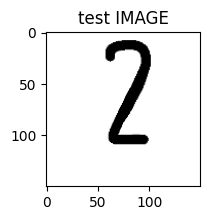

In [5]:
imshow("test IMAGE",image_test,2)

In [6]:
image_test.shape

(150, 150)

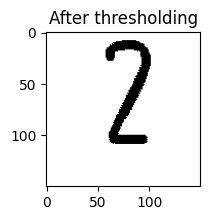

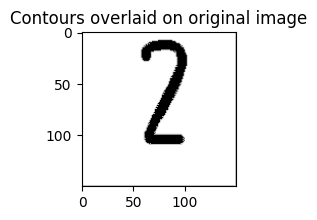

In [51]:
_, th2 = cv2.threshold(image_test, 0, 255, cv2.THRESH_BINARY + cv2.ACCESS_FAST)
imshow('After thresholding', th2,2)

# Finding Contours
# Use a copy of your image e.g. edged.copy(), since findContours alters the image
contours, hierarchy = cv2.findContours(image_test, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)

# Draw all contours, note this overwrites the input image (inplace operation)
# Use '-1' as the 3rd parameter to draw all
cv2.drawContours(image_test, contours, -1, (200,0,0), thickness = 1)
imshow('Contours overlaid on original image', image_test,2)

In [16]:
train_datagen = ImageDataGenerator(rescale=1.0/255,
                                  rotation_range=15,
                                  zoom_range=0.2,
                                  width_shift_range=0.3,
                                  height_shift_range=0.3)
train_generator = train_datagen.flow_from_directory(
    train_image_path,              # Path to the root folder
    target_size=(150, 150), # Resize images to this size
    batch_size=16,
    class_mode='categorical'  # or 'binary', 'sparse', 'input', or None
)

Found 42749 images belonging to 14 classes.


In [8]:
print(train_generator.class_indices)

{'add': 0, 'divide': 1, 'eight': 2, 'five': 3, 'four': 4, 'multiply': 5, 'nine': 6, 'one': 7, 'seven': 8, 'six': 9, 'subtract': 10, 'three': 11, 'two': 12, 'zero': 13}


In [17]:
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(test_image_path,              # Path to the root folder
    target_size=(150, 150), # Resize images to this size
    batch_size=16,
    class_mode='categorical'  # or 'binary', 'sparse', 'input', or None
)

Found 5356 images belonging to 14 classes.


In [21]:
validation_datagen = ImageDataGenerator(rescale=1.0/255)
val_generator=validation_datagen.flow_from_directory(
    validation_image_path,
    target_size=(150, 150),
    batch_size=16,
    class_mode='categorical'
)

Found 5337 images belonging to 14 classes.


In [48]:
type(val_generator[0])

tuple

In [39]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow.keras.optimizers as optimizers
devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  details = tf.config.experimental.get_device_details(gpus[0])
  print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU details:  {'device_name': 'METAL'}


In [32]:
model = Sequential()
model.add(Conv2D(32,(3,3)),)

In [64]:
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(150, 150,3)),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.23),
    Dense(14, activation='softmax')
])

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.25,        # reduce by 1/4
    patience=1,        # after 1 epochs with no improvement
    verbose=1,
    min_lr=1e-8
)


In [65]:
model.compile(optimizer=optimizers.Adagrad(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
model.fit(train_generator, epochs=12, validation_data=val_generator,callbacks=[lr_scheduler])

Epoch 1/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.0912 - loss: 2.6348 - val_accuracy: 0.1538 - val_loss: 2.4897 - learning_rate: 0.0010
Epoch 2/12
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.1780 - loss: 2.4763 - val_accuracy: 0.3022 - val_loss: 2.1257 - learning_rate: 0.0010
Epoch 3/12
1746/2672 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.2893 - loss: 2.2386 

In [44]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 9.4 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
